Step 1. Load the data
Load all data files and convert the date column into real dates.

In [2]:
# Import libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns when printing tables
pd.set_option("display.max_columns", None)

# Load the files. "../" means go up one folder from notebooks/ to the project root
# parse_dates turns the 'date' text into real dates we can sort and group by
train = pd.read_csv("../data/train-test.csv", parse_dates=["date"])
valid = pd.read_csv("../data/validation.csv", parse_dates=["date"])
dec = pd.read_csv("../data/december-chart-inputs.csv", parse_dates=["date"])

# Shape = (rows, columns)
print("Train:", train.shape)
print("Validation:", valid.shape)
print("December:", dec.shape)

Train: (48000, 14)
Validation: (12000, 13)
December: (31, 7)


Step 2. First look at the columns
Check column names, data types, and a few sample rows.

In [3]:
# Show the first 5 rows to see what each column contains
display(train.head())

# Show the data type of each column (numbers, text, dates)
print(train.dtypes)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object


Step 3. Missing values
Count empty values in each column for training and validation data.

In [4]:
# Count missing values per column for both datasets, side by side
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "valid_missing": valid.isna().sum(),
})

# Show only the columns that have at least one missing value
print(missing[missing.sum(axis=1) > 0])

              train_missing  valid_missing
market_index            374          249.0
weight                  300          165.0


Step 4. Duplicates
Check whether any load appears twice.

In [5]:
# Same load_id twice would mean a repeated load
print("Duplicate load_ids:", train["load_id"].duplicated().sum())

# Rows identical in every column except load_id (possible copy errors)
print("Duplicate rows (ignoring id):", train.drop(columns="load_id").duplicated().sum())

Duplicate load_ids: 0
Duplicate rows (ignoring id): 0


Step 5. Numeric summary
Summary statistics to spot impossible values (negatives) and extreme values.

In [6]:
# Count, mean, min, max and percentiles for every numeric column
# .T flips the table so each column becomes a row (easier to read)
# Look at the 'min' of weight and the 'max' of posted_rate
display(train.describe().T)

,count,mean,min,25%,50%,75%,max,std
pickup_lat,48000.0,35.647545,28.35765,31.98691,35.29479,39.41104,44.30296,4.315285
pickup_lon,48000.0,-90.928964,-121.69849,-98.40059,-88.08915,-83.28506,-69.5,13.482431
delivery_lat,48000.0,35.641175,28.35765,31.98691,35.29479,39.41104,44.30296,4.317199
delivery_lon,48000.0,-90.85731,-121.69849,-98.40059,-87.52871,-83.28506,-69.5,13.476589
distance,48000.0,1135.856654,70.0,550.4,953.3,1645.525,3439.8,728.564416
weight,47700.0,31028.844004,-47500.0,25800.0,31436.5,37018.0,47500.0,9391.44062
date,48000,2025-05-31 19:53:29.400000,2025-01-01 00:00:00,2025-03-18 00:00:00,2025-05-31 00:00:00,2025-08-15 00:00:00,2025-10-31 00:00:00,NaN
market_index,47626.0,1.083387,0.67639,0.94967,1.0558,1.21959,1.46778,0.168091
quote_signal,48000.0,2.062468,0.69228,1.89103,2.05575,2.221685,3.61035,0.291391
posted_rate,48000.0,2373.980682,57.22,1251.555,2030.76,3330.75,25533.0,1486.493245


Step 6. Equipment, cities and lanes
Look at equipment types and check whether validation has cities or lanes never seen in training.

In [7]:
# Number of loads per equipment type
print(train["equipment"].value_counts(), "\n")

# A 'lane' is a pickup -> delivery pair
train_lanes = set(zip(train["pickup"], train["delivery"]))
valid_lanes = set(zip(valid["pickup"], valid["delivery"]))
print("Lanes in training:", len(train_lanes))
print("Lanes in validation:", len(valid_lanes))
print("Validation lanes never seen in training:", len(valid_lanes - train_lanes), "\n")

# Cities in validation that never appear anywhere in training
train_cities = set(train["pickup"]) | set(train["delivery"])
valid_cities = set(valid["pickup"]) | set(valid["delivery"])
new_cities = valid_cities - train_cities
print("New cities in validation:", sorted(new_cities))

# How many validation loads involve at least one new city
uses_new_city = valid["pickup"].isin(new_cities) | valid["delivery"].isin(new_cities)
print(f"Validation loads with a new city: {uses_new_city.sum():,} ({uses_new_city.mean():.1%})")

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64 

Lanes in training: 4014
Lanes in validation: 4214
Validation lanes never seen in training: 736 

New cities in validation: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Validation loads with a new city: 1,447 (12.1%)


Step 7. Target distribution
Look at posted_rate (the value we predict) on a normal and a log scale.

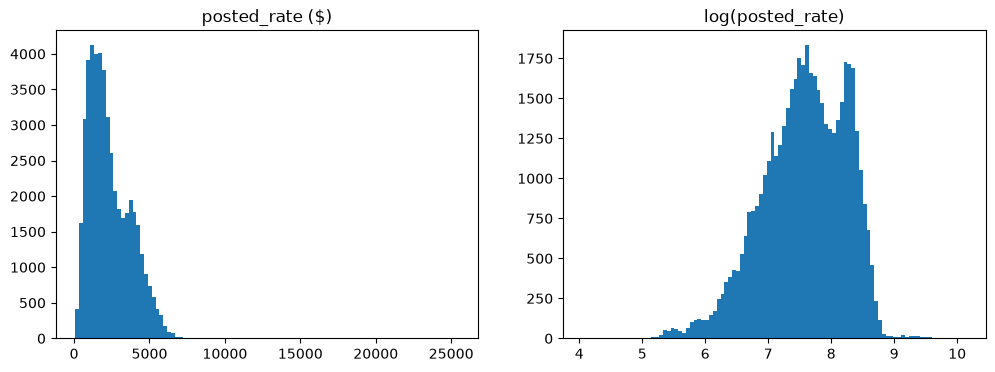

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw rate: skewed, with a long tail of expensive loads
axes[0].hist(train["posted_rate"], bins=100)
axes[0].set_title("posted_rate ($)")

# Log of the rate: spreads values out so the shape is easier to see
axes[1].hist(np.log(train["posted_rate"]), bins=100)
axes[1].set_title("log(posted_rate)")

plt.show()

Step 8. Rate per mile and outliers
Rate per mile removes the effect of distance, so unrealistic prices stand out.

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64


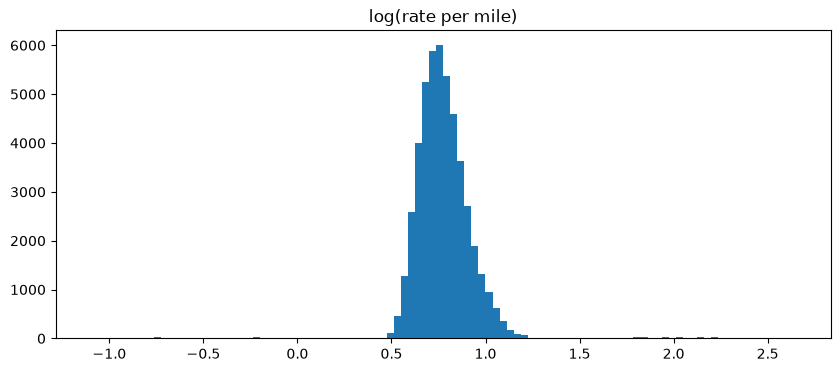

Normal range: 0.92 to 3.41 $/mile
Outliers: 663 (1.4% of rows)


,pickup,delivery,distance,equipment,posted_rate,rate_per_mile
14102,Buffalo,Bakersfield,2536.4,Dry Van,846.42,0.333709
25798,Albany,Reno,2894.3,Dry Van,969.83,0.335083
23043,Phoenix,Philadelphia,2983.4,Dry Van,1047.91,0.351247
46173,Philadelphia,El Paso,2490.9,Dry Van,880.13,0.353338
508,Las Vegas,Grand Rapids,1976.4,Flatbed,699.41,0.353881


,pickup,delivery,distance,equipment,posted_rate,rate_per_mile
27969,Buffalo,Boston,589.9,Reefer,7597.52,12.879335
17070,Toledo,Dayton,201.5,Flatbed,2609.34,12.949578
870,Tulsa,Baton Rouge,305.6,Reefer,4069.24,13.315576
36609,Chattanooga,Atlanta,98.4,Reefer,1386.42,14.089634
22254,Greensboro,Cincinnati,314.7,Reefer,4445.23,14.125294


In [9]:
# Rate per mile = price divided by distance (standard trucking price measure)
train["rate_per_mile"] = train["posted_rate"] / train["distance"]
print(train["rate_per_mile"].describe())

# Log histogram: small separate clusters far from the main peak = likely data errors
plt.figure(figsize=(10, 4))
plt.hist(np.log(train["rate_per_mile"]), bins=100)
plt.title("log(rate per mile)")
plt.show()

# Flag extreme values with a wide IQR rule (3x IQR, stricter than the usual 1.5x)
q1, q3 = train["rate_per_mile"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 3 * iqr, q3 + 3 * iqr
outliers = train[(train["rate_per_mile"] < low) | (train["rate_per_mile"] > high)]
print(f"Normal range: {low:.2f} to {high:.2f} $/mile")
print(f"Outliers: {len(outliers):,} ({len(outliers) / len(train):.1%} of rows)")

# Show the lowest and highest examples
cols = ["pickup", "delivery", "distance", "equipment", "posted_rate", "rate_per_mile"]
display(outliers.sort_values("rate_per_mile")[cols].head(5))
display(outliers.sort_values("rate_per_mile")[cols].tail(5))

Step 9. Weight problems
Check for negative weights, which are physically impossible.

Non-positive weights in train: 292
Non-positive weights in validation: 145
count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64


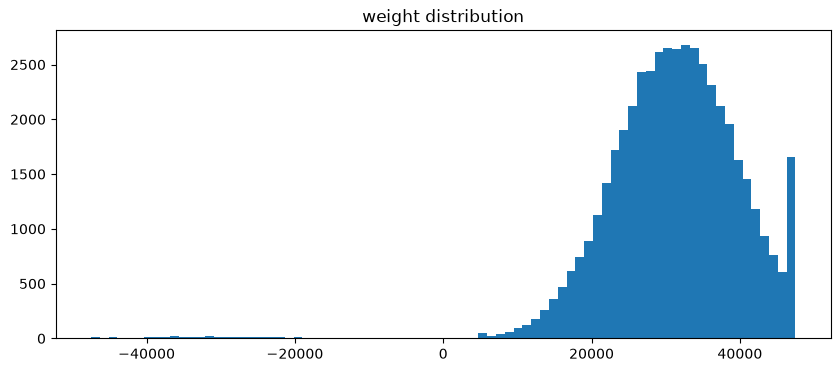

In [10]:
# A weight must be positive; negative values are data errors
neg_weight = train[train["weight"] <= 0]
print("Non-positive weights in train:", len(neg_weight))
print("Non-positive weights in validation:", (valid["weight"] <= 0).sum())
print(neg_weight["weight"].describe())

# If the negative values mirror the positive ones, it's likely a flipped sign
plt.figure(figsize=(10, 4))
plt.hist(train["weight"].dropna(), bins=80)
plt.title("weight distribution")
plt.show()

Step 10. Distance sanity check
Compare the given road distance with the straight-line distance from coordinates.

In [11]:
# Haversine formula: straight-line distance in miles between two lat/lon points
R = 3958.8  # Earth's radius in miles
lat1, lon1, lat2, lon2 = map(np.radians, [
    train["pickup_lat"], train["pickup_lon"],
    train["delivery_lat"], train["delivery_lon"],
])
a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
train["straight_line_miles"] = 2 * R * np.arcsin(np.sqrt(a))

# Road distance is normally about 1.1 to 1.3 times the straight line
train["distance_ratio"] = train["distance"] / train["straight_line_miles"]
print(train["distance_ratio"].describe())

# Show rows where the road distance is much longer than the straight line
display(train[train["distance_ratio"] > 2.5][
    ["pickup", "delivery", "distance", "straight_line_miles"]
].head(10))

# Does the same lane always have the same distance? Check min/max per lane
lane_dist = train.groupby(["pickup", "delivery"])["distance"].agg(["min", "max", "count"])
display(lane_dist.head(10))

count    48000.000000
mean         1.194681
std          0.143541
min          1.058090
25%          1.164765
50%          1.182231
75%          1.204765
max          9.634919
Name: distance_ratio, dtype: float64


,pickup,delivery,distance,straight_line_miles
4140,New Orleans,Shreveport,70.0,7.26524
5091,New Orleans,Shreveport,70.0,7.26524
6960,New Orleans,Shreveport,70.0,7.26524
9348,Shreveport,New Orleans,70.0,7.26524
11949,Shreveport,New Orleans,70.0,7.26524
12480,New Orleans,Shreveport,70.0,7.26524
15756,Shreveport,New Orleans,70.0,7.26524
16351,New Orleans,Shreveport,70.0,7.26524
34136,Shreveport,New Orleans,70.0,7.26524
37183,Shreveport,New Orleans,70.0,7.26524


min     max  count
pickup delivery                          
Albany Albuquerque  2412.0  2526.2     14
       Amarillo     2184.6  2318.8     18
       Atlanta      1172.6  1240.3     19
       Austin       2134.3  2214.3      6
       Bakersfield  2841.1  3035.4     14
       Baltimore     479.8   508.7      8
       Baton Rouge  1693.6  1809.5     21
       Birmingham   1264.7  1327.0      7
       Boston        394.7   418.2     13
       Buffalo       474.7   523.0     10

Step 11. Market index behaviour
Check whether market_index is the same for all loads on a day (a daily market value).

In [12]:
# For each date: average market_index and how much it varies between loads that day
daily_spread = train.groupby("date")["market_index"].agg(["mean", "std"])
display(daily_spread.head())

# If loads on the same day barely differ, but days differ a lot, it's a daily value
# and missing values can be filled with that day's average
print("Average variation within a day:", round(daily_spread["std"].mean(), 4))
print("Variation between days:", round(daily_spread["mean"].std(), 4))

,mean,std
date,,
2025-01-01,0.961224,0.024493
2025-01-02,0.986606,0.025281
2025-01-03,0.940339,0.026063
2025-01-04,0.857702,0.023678
2025-01-05,0.801855,0.024737


Average variation within a day: 0.0249
Variation between days: 0.1665


Step 12. Time trend
See how rates and the market index change month by month.

,median_rpm,avg_market_index,loads
date,,,
1,2.029158,0.926696,4918
2,2.061143,0.995997,4337
3,2.139279,1.072880,5036
4,2.146699,1.207649,4819
5,2.190194,1.301452,4913
6,2.247885,1.280316,4783
7,2.187422,1.200893,4912
8,2.120525,0.981480,4759
9,2.159622,0.893039,4670


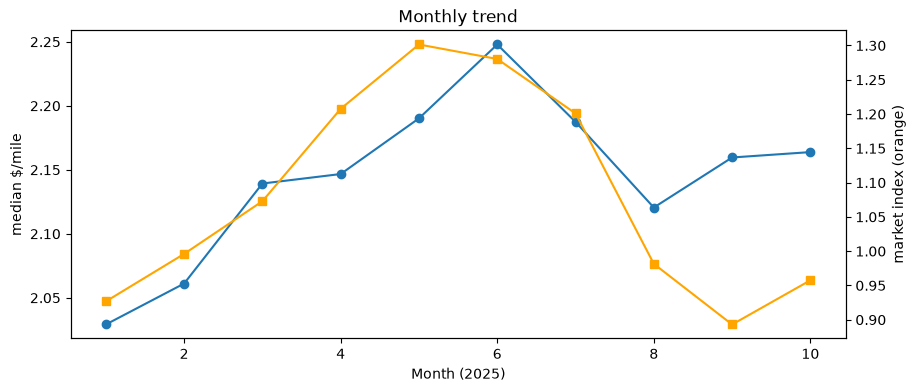

Train dates: 2025-01-01 to 2025-10-31
Validation dates: 2025-11-01 to 2025-12-31


In [13]:
# Monthly median rate per mile, average market index and number of loads
monthly = train.groupby(train["date"].dt.month).agg(
    median_rpm=("rate_per_mile", "median"),
    avg_market_index=("market_index", "mean"),
    loads=("load_id", "count"),
)
display(monthly)

# Plot both on one chart with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly.index, monthly["median_rpm"], marker="o")
ax1.set_xlabel("Month (2025)")
ax1.set_ylabel("median $/mile")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["avg_market_index"], marker="s", color="orange")
ax2.set_ylabel("market index (orange)")
plt.title("Monthly trend")
plt.show()

# Date ranges: validation comes AFTER training, so we need a time-based split
print("Train dates:", train["date"].min().date(), "to", train["date"].max().date())
print("Validation dates:", valid["date"].min().date(), "to", valid["date"].max().date())

Step 13. Day of week and equipment effects
Check whether weekday or equipment type changes prices and the market index.

In [14]:
# Average market index by weekday (shows a weekly cycle)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print(train.groupby(train["date"].dt.day_name())["market_index"].mean().reindex(weekday_order), "\n")

# Median rate per mile by equipment (Reefer and Flatbed usually cost more)
print(train.groupby("equipment")["rate_per_mile"].median())

date
Monday       0.999586
Tuesday      1.075435
Wednesday    1.153226
Thursday     1.178978
Friday       1.134310
Saturday     1.047481
Sunday       0.988633
Name: market_index, dtype: float64 

equipment
Dry Van    2.046203
Flatbed    2.219683
Reefer     2.311540
Name: rate_per_mile, dtype: float64


Step 14. Correlations
See which numeric features move together with rate per mile.

In [15]:
# Correlation ranges from -1 to 1; values near 0 mean no straight-line relationship
cols = ["rate_per_mile", "distance", "weight", "market_index", "quote_signal"]
display(train[cols].corr().round(2))

,rate_per_mile,distance,weight,market_index,quote_signal
rate_per_mile,1.00,-0.33,0.07,0.08,0.05
distance,-0.33,1.00,0.00,-0.00,-0.06
weight,0.07,0.00,1.00,-0.00,0.01
market_index,0.08,-0.00,-0.00,1.00,-0.07
quote_signal,0.05,-0.06,0.01,-0.07,1.00


Step 15. Train vs validation comparison
Check that the validation data looks similar to the training data.

In [16]:
# Compare averages and spreads of shared numeric features
features = ["distance", "weight", "market_index", "quote_signal"]
compare = pd.DataFrame({
    "train_mean": train[features].mean(),
    "valid_mean": valid[features].mean(),
    "train_std": train[features].std(),
    "valid_std": valid[features].std(),
})
display(compare.round(3))

# Compare the equipment mix as percentages
print(pd.concat([
    train["equipment"].value_counts(normalize=True).rename("train"),
    valid["equipment"].value_counts(normalize=True).rename("valid"),
], axis=1).round(3))

,train_mean,valid_mean,train_std,valid_std
distance,1135.857,1141.773,728.564,732.334
weight,31028.844,30506.636,9391.441,10572.590
market_index,1.083,0.927,0.168,0.074
quote_signal,2.062,2.051,0.291,0.220


           train  valid
equipment              
Dry Van    0.567  0.565
Reefer     0.251  0.254
Flatbed    0.182  0.181


In [ ]:
Step 16. December chart inputs
Check which columns the December file lacks, since the model must still predict it.

In [17]:
display(dec.head())

# Columns the model could use that the December file does not have
print("Missing in December file:", set(valid.columns) - set(dec.columns) - {"load_id"})

# How many similar loads exist in training for this exact lane and equipment
same_lane = train[
    (train["pickup"] == "Lexington")
    & (train["delivery"] == "Fort Wayne")
    & (train["equipment"] == "Dry Van")
]
print("Lexington -> Fort Wayne Dry Van loads in training:", len(same_lane))

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


Missing in December file: {'quote_signal', 'delivery_lon', 'market_index', 'delivery_lat', 'pickup_lon', 'pickup_lat'}
Lexington -> Fort Wayne Dry Van loads in training: 21


## Key findings

### 1. Data size and time range
- Training: 48,000 loads from Jan 1 to Oct 31, 2025. Validation: 12,000 loads from Nov 1 to Dec 31, 2025.
- Validation is entirely in the future relative to training, so a random train/test split would leak
  future information. **Decision: use time-based validation (train on past months, test on the next 2 months).**
- No duplicate loads or duplicate rows.

### 2. Missing values
- `market_index` is missing in 374 training rows and 249 validation rows (~0.8%).
- `weight` is missing in 300 training rows and 165 validation rows (~0.6%).

### 3. market_index is a daily market value
- Loads on the same day have almost the same index (average within-day variation 0.025),
  while days differ a lot (variation between days 0.167).
- It also has a clear weekly cycle: highest Wed–Thu (~1.17), lowest Sun–Mon (~0.99).
- **Decision: fill missing market_index with that date's daily average**, which is a very accurate estimate.

### 4. Data-quality issue: negative weights
- 292 training and 145 validation rows have negative weights (-5,000 to -47,500 lb).
- Their values mirror the normal positive range, which points to a flipped sign, not random noise.
- **Decision: use the absolute value** instead of deleting rows.
- There is also a spike at exactly 47,500 lb, which looks like a maximum cap; left as is.

### 5. Data-quality issue: impossible prices
- Normal rate per mile is about $2.15 (most loads between $0.92 and $3.41/mile).
- 663 loads (1.4%) are far outside this range, e.g. $14/mile or $0.33/mile. They form separate
  clusters in the log histogram, which looks like data-entry/scaling errors, not real prices.
- **Decision: remove them from training only** (they would distort the model), but keep them
  in test windows so the reported error is honest.

### 6. Distance and coordinates
- Road distance is normally ~1.18x the straight-line distance, as expected.
- Distances for the same lane vary by a few percent, and very short lanes appear capped at a
  70-mile minimum (e.g. New Orleans–Shreveport). Coordinates look approximate, not exact.

### 7. New cities in validation (biggest risk)
- 8 cities appear in validation but never in training (Allentown, Charlotte, Chicago, Jackson,
  Knoxville, Laredo, Norfolk, San Diego), affecting 1,447 validation loads (12.1%).
- 736 validation lanes were never seen in training.
- **Decision: describe cities by latitude/longitude instead of by name**, so the model can
  price an unseen city from its location and nearby known cities.

### 8. What drives price
- Distance is the strongest driver: rate per mile drops as distance grows (correlation -0.33),
  because short trips have fixed costs spread over fewer miles.
- Equipment matters: Dry Van ~$2.05/mile, Flatbed ~$2.22, Reefer ~$2.31.
- Prices follow the market index from Jan to Jul (both peak around May–Jun), but from Aug to Oct
  the index falls while rates stay high. So the market level drifts over time in ways the index
  alone doesn't explain.
- **Decision: weight recent loads more heavily in training (recency weighting).**
- The log of posted_rate has two peaks because of the mix of short and long trips; predicting
  log(rate per mile) removes most of this distance effect.

### 9. Train vs validation differences
- Distance and equipment mix are almost identical between the two sets.
- market_index is lower and steadier in validation (mean 0.93 vs 1.08), consistent with a
  quieter Nov–Dec market. All its values are still within the training range.

### 10. December chart file
- It lacks coordinates, market_index, and quote_signal.
- **Decision:** take Lexington and Fort Wayne coordinates from the training data, use each
  December day's average market_index from validation.csv, and use the median quote_signal.
- The lane is well covered: 21 Lexington → Fort Wayne Dry Van loads in training.